<a href="https://colab.research.google.com/github/AvichalTrivedi7/ANN-Deep-Learning-5th-Semester/blob/main/Lab6_Keras_MLP_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practical 6: Keras MLP for Regression

Practicals 4 and 5 both predicted a *category*. This one predicts a *number*: the median house price of a California district, from census features.

The point of the practical is not to get one model working. It is to compare three activation functions and three loss functions and explain **why** each behaves the way it does, from the properties of this specific dataset. So the notebook is built around two questions that can actually be answered by measurement rather than asserted:

1. Why does the choice of activation change how fast the model converges?
2. Why would anyone use MAE or Huber when MSE is the standard regression loss?

**Pipeline:** census features, scaling, hidden layers (activation under test), single linear output neuron, regression loss under test, predicted price.

## What changes from Practicals 4 and 5

The output end changes again, and this time it gets simpler rather than more complex.

| | Practical 4 (multiclass) | Practical 5 (binary) | Practical 6 (regression) |
|---|---|---|---|
| Output neurons | 4 | 1 | 1 |
| Output activation | softmax | sigmoid | **none (linear)** |
| Loss | categorical crossentropy | binary crossentropy | **MSE / MAE / Huber** |
| Reading the answer | `argmax` | `>= 0.5` | the number itself |
| Metric | accuracy | accuracy | MAE, RMSE, R2 |

The single most important line in the whole notebook is the output layer having **no activation function**. In every previous practical the final activation squashed the output into a fixed range: sigmoid into (0,1), softmax into a set of probabilities summing to 1. A price is not bounded like that, so squashing it would make the target unreachable. Leaving the output linear lets the network produce any real number.

The second change is that the loss is now a **distance** rather than a measure of surprise. Crossentropy asked "how much probability did you put on the right class". A regression loss asks "how far off was the number", and the three candidates differ entirely in how they answer that when the miss is large.

### In layman terms: how the three losses differ

All three measure error. They disagree about how much a *big* error should count.

- **MSE** squares the error. Being off by 4 is not 4 times as bad as being off by 1, it is 16 times as bad. Big misses dominate everything.
- **MAE** takes the absolute value. Being off by 4 is exactly 4 times as bad as being off by 1. Every error counts in proportion.
- **Huber** switches between the two. Inside a threshold `delta` it behaves like MSE, beyond it like MAE.

```
error size        MSE says      MAE says     Huber says (delta=1)
    0.5             0.25          0.5           quadratic, like MSE
    1.0             1.00          1.0           the switch point
   10.0           100.00         10.0           linear, like MAE
```

The consequence: if a training example has a wrong label that is wildly off, MSE will contort the whole model to reduce that one enormous squared error, because it dominates the sum. MAE and Huber refuse to chase it.

Whether that matters depends completely on whether the dataset contains such examples. So the first thing to do is look.

## Dataset description and source

**California Housing**, from the 1990 US Census. Each row is a census block group (called a district here), roughly 600 to 3000 residents.

Source: `https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv`, the copy used in *Hands-On Machine Learning* (Geron), derived from Pace and Barry (1997).

**Target:** `median_house_value`, the median house price in the district, in US dollars. Continuous, so this is a regression problem.

**Features:** 8 numeric (location, house age, room and population counts, median income) plus 1 categorical (`ocean_proximity`).

I chose this dataset over a cleaner one deliberately, because it needs real preprocessing work: it has missing values, a categorical column, features on wildly different scales, and one specific quirk in the target that turns the loss function comparison into something I can actually prove instead of assert.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("housing.csv")
print("shape:", df.shape)
print("\ncolumns and types:")
print(df.dtypes)
print("\nfirst 3 rows:")
print(df.head(3).to_string())

I0000 00:00:1786822051.489487   10036 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1786822051.553472   10036 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1786822053.533207   10036 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


shape: (20640, 10)

columns and types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

first 3 rows:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  population  households  median_income  median_house_value ocean_proximity
0    -122.23     37.88                41.0        880.0           129.0       322.0       126.0         8.3252            452600.0        NEAR BAY
1    -122.22     37.86                21.0       7099.0          1106.0      2401.0      1138.0         8.3014            358500.0        NEAR BAY
2    -122.24     37.85                52.0       1467.0           190.0       496.0       177.0         7.2574            352100.0        NEAR BAY


In [ ]:
print("Missing values per column:")
miss = df.isna().sum()
print(miss[miss > 0])
print(f"\n-> {miss.sum()} missing values, all in one column ({100*miss.max()/len(df):.2f}% of rows)")

print("\nCategorical column, value counts:")
print(df['ocean_proximity'].value_counts())

print("\nFeature scales (min and max):")
print(df.select_dtypes('number').describe().loc[['min','max']].T.to_string())

Missing values per column:
total_bedrooms    207
dtype: int64

-> 207 missing values, all in one column (1.00% of rows)

Categorical column, value counts:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

Feature scales (min and max):
                           min          max
longitude            -124.3500    -114.3100
latitude               32.5400      41.9500
housing_median_age      1.0000      52.0000
total_rooms             2.0000   39320.0000
total_bedrooms          1.0000    6445.0000
population              3.0000   35682.0000
households              1.0000    6082.0000
median_income           0.4999      15.0001
median_house_value  14999.0000  500001.0000


#### Observation
Three preprocessing problems, all of which have to be handled before anything can be trained:

1. **Missing values.** 207 rows are missing `total_bedrooms`, about 1% of the data. Small enough that dropping them would be acceptable, but imputing keeps the rows.
2. **A categorical column.** `ocean_proximity` is text, and a `Dense` layer only consumes numbers. Note `ISLAND` has only 5 rows, which is worth remembering.
3. **Feature scales that differ by four orders of magnitude.** `total_rooms` runs up to 39320 while `latitude` sits around 35. Practical 4 already showed what happens if this is ignored: the large-numbered features dominate the gradient updates and the small ones are effectively invisible.

Target: median_house_value
count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000

Three highest distinct values in the target: [499100. 500000. 500001.]
Rows sitting at the maximum: 992 (4.81% of the dataset)


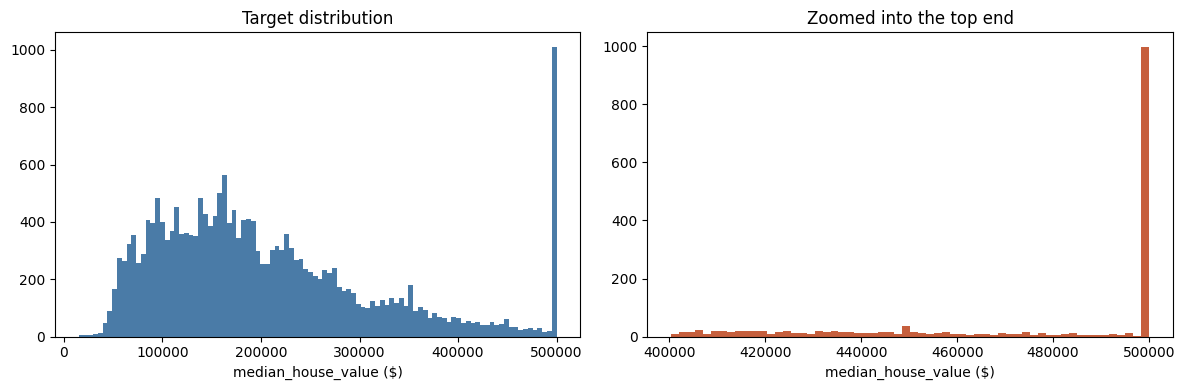

In [ ]:
target = df['median_house_value']
print("Target: median_house_value")
print(target.describe().to_string())

top = np.sort(target.unique())[-3:]
print(f"\nThree highest distinct values in the target: {top}")
n_cap = (target >= 500000).sum()
print(f"Rows sitting at the maximum: {n_cap} ({100*n_cap/len(df):.2f}% of the dataset)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(target, bins=100, color='#4a7ba7')
axes[0].set_title("Target distribution"); axes[0].set_xlabel("median_house_value ($)")
axes[1].hist(target[target > 400000], bins=60, color='#c65f3d')
axes[1].set_title("Zoomed into the top end"); axes[1].set_xlabel("median_house_value ($)")
plt.tight_layout(); plt.show()

#### Observation: the quirk that drives the whole loss comparison
The histogram has a normal-looking right tail that falls away smoothly, and then a **spike at the very top**. 992 districts, 4.81% of the dataset, are recorded at exactly 500001 dollars.

That is not what genuinely expensive housing looks like. Real prices do not pile up on a single value. This is a **hard cap applied when the data was collected**: any district worth more than half a million dollars was recorded as half a million dollars.

Worth confirming rather than assuming, because the entire loss function argument rests on it.

In [ ]:
capped = target >= 500000
print("If these were genuinely the priciest districts, they should look uniformly wealthy.")
print(f"\nmedian_income within capped rows: min {df.loc[capped,'median_income'].min():.2f}, "
      f"max {df.loc[capped,'median_income'].max():.2f}, median {df.loc[capped,'median_income'].median():.2f}")
print(f"median_income across whole dataset: min {df['median_income'].min():.2f}, "
      f"max {df['median_income'].max():.2f}")
print("\nocean_proximity within capped rows:")
print(df.loc[capped,'ocean_proximity'].value_counts().to_string())

If these were genuinely the priciest districts, they should look uniformly wealthy.

median_income within capped rows: min 0.50, max 15.00, median 7.56
median_income across whole dataset: min 0.50, max 15.00

ocean_proximity within capped rows:
ocean_proximity
<1H OCEAN     541
NEAR OCEAN    221
NEAR BAY      202
INLAND         28


#### Observation
The capped rows span the **entire income range of the dataset**, from 0.5 to 15.0, and include 28 inland districts. Districts with a median income of 0.5 and districts with a median income of 15.0 are both recorded at exactly the same house price.

That settles it. These are not genuinely the 992 most expensive districts, they are 992 districts whose true prices were **truncated to a ceiling**. Their real values differ enormously from each other and all of them are higher than what is recorded.

**Why this decides the loss function.** For a model that has learned the genuine relationship between income and price, a wealthy capped district will look like it should cost far more than 500001. The model predicts high, the recorded label says 500001, and the model is charged a large error for being right. Under MSE that error gets **squared**, so these 992 rows exert influence out of all proportion to their number, and the model is pushed to distort its fit for the other 19648 rows in order to reduce them.

That is precisely the situation MAE and Huber exist for. So the loss comparison in this notebook is not "try three and see", it is a hypothesis with a mechanism, and it can be tested.

## Data preprocessing

Five steps, each with a reason.

**1. Impute missing values with the median.** Median rather than mean because `total_bedrooms` is strongly right skewed (a few districts have thousands), and the mean of a skewed column is pulled toward the tail.

**2. Engineer three ratio features.** `total_rooms` for a district is nearly meaningless on its own, since it mostly reflects how many households live there. Rooms *per household* is the quantity that actually says something about house size. Same reasoning for `bedrooms_per_room` and `population_per_household`.

**3. One-hot encode `ocean_proximity`.** Five categories become five 0/1 columns. Deliberately not integer-encoded (0,1,2,3,4), because that would tell the network `NEAR OCEAN` is greater than `INLAND` and that the gap between categories is uniform, neither of which is true.

**4. Scale the features** with `StandardScaler`, fitted on the training set only so no information leaks from the test set.

**5. Rescale the target into units of 100000 dollars.** Prices in raw dollars produce squared errors in the billions, which makes losses awkward to read and the gradients large. Dividing by 100000 puts the target in a range of roughly 0.15 to 5.0. This also makes Huber's default `delta=1.0` meaningful: it becomes a threshold of 100000 dollars, which is a sensible boundary between an ordinary miss and a large one.

In [ ]:
data = df.copy()
data['total_bedrooms'] = data['total_bedrooms'].fillna(data['total_bedrooms'].median())

data['rooms_per_household']      = data['total_rooms'] / data['households']
data['bedrooms_per_room']        = data['total_bedrooms'] / data['total_rooms']
data['population_per_household'] = data['population'] / data['households']

data = pd.get_dummies(data, columns=['ocean_proximity'], prefix='ocean')

y_all = data.pop('median_house_value').values.astype('float32') / 100000.0
X_all = data.values.astype('float32')
feature_names = list(data.columns)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42)

scaler = StandardScaler().fit(X_train_raw)
X_train = scaler.transform(X_train_raw).astype('float32')
X_test  = scaler.transform(X_test_raw).astype('float32')

print(f"features after preprocessing: {len(feature_names)}")
print(feature_names)
print(f"\ntrain {X_train.shape[0]} rows, test {X_test.shape[0]} rows")
print(f"missing values remaining: {np.isnan(X_train).sum() + np.isnan(X_test).sum()}")
print(f"target range (units of $100k): {y_train.min():.2f} to {y_train.max():.2f}, mean {y_train.mean():.3f}")

is_capped_test = y_test >= 5.0
print(f"\ncapped rows in test set: {is_capped_test.sum()} ({100*is_capped_test.mean():.2f}%)")

features after preprocessing: 16
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'ocean_<1H OCEAN', 'ocean_INLAND', 'ocean_ISLAND', 'ocean_NEAR BAY', 'ocean_NEAR OCEAN']

train 16512 rows, test 4128 rows
missing values remaining: 0
target range (units of $100k): 0.15 to 5.00, mean 2.072

capped rows in test set: 184 (4.46%)


## Baselines before any neural network

Same discipline as Practicals 4 and 5. An R2 of 0.75 means nothing until I know what trivial approaches score.

- **Predict the mean every time.** This is the definition of R2 = 0, and it is the honest floor.
- **Linear regression.** The no-hidden-layer model, exactly the comparison used in the previous two practicals. If the MLP cannot beat this, the hidden layers are decoration.

In [ ]:
mean_pred = np.full_like(y_test, y_train.mean())
lin = LinearRegression().fit(X_train, y_train)
lin_pred = lin.predict(X_test)

def report(name, pred, truth=y_test):
    mae  = mean_absolute_error(truth, pred)
    rmse = float(np.sqrt(mean_squared_error(truth, pred)))
    r2   = r2_score(truth, pred)
    print(f"{name:<22} MAE {mae:.4f} (${mae*100000:,.0f})   RMSE {rmse:.4f}   R2 {r2:.4f}")
    return mae, rmse, r2

print("Baselines (MAE and RMSE in units of $100k, dollar value in brackets)\n")
report("predict the mean", mean_pred)
report("linear regression", lin_pred)

Baselines (MAE and RMSE in units of $100k, dollar value in brackets)

predict the mean       MAE 0.9061 ($90,607)   RMSE 1.1449   R2 -0.0002
linear regression      MAE 0.5089 ($50,889)   RMSE 0.7267   R2 0.5970


(0.5088866353034973, 0.726685421297718, 0.5970176458358765)

#### Observation
Predicting the mean gives R2 of essentially zero (-0.0002, the tiny negative coming from the test split having a marginally different mean than the training split), with an average miss of about 90600 dollars. That is the floor.

Linear regression reaches R2 0.5970 with an average miss of about 50900 dollars, so a straight-line combination of the features already explains roughly 60% of the variation in price. **That is the number the MLP has to beat, not zero.** Setting it up front prevents the mistake of reporting 0.77 as though it were impressive without context.

## MLP architecture

The same shape used for all experiments, so the activation and loss comparisons are like for like.

```
Input (16 features)
    |
Dense(64, activation under test)
    |
Dense(32, activation under test)
    |
Dense(1)                      <- linear, no activation
```

Two hidden layers as the practical requires. 64 and 32 units, tapering, following the same reasoning as Practical 4: start with the smallest architecture that reaches the achievable ceiling rather than the biggest that fits.

Adam at learning rate 0.001, batch size 128, 60 epochs, 20% of the training set held out for validation. These are held fixed across every experiment. The only things that change are the activation and the loss.

In [ ]:
def build_mlp(activation, loss, seed=42, input_dim=None):
    tf.keras.backend.clear_session()
    tf.random.set_seed(seed)
    d = input_dim if input_dim is not None else X_train.shape[1]
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(d,)),
        tf.keras.layers.Dense(64, activation=activation, name='h1'),
        tf.keras.layers.Dense(32, activation=activation, name='h2'),
        tf.keras.layers.Dense(1)                       # linear output for regression
    ])
    loss_fn = {'mse':'mse', 'mae':'mae', 'huber':tf.keras.losses.Huber(delta=1.0)}[loss]
    model.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss=loss_fn, metrics=['mae'])
    return model

demo = build_mlp('relu', 'mse')
demo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ h1 (Dense)                      │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h2 (Dense)                      │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,201 (12.50 KB)

 Trainable params: 3,201 (12.50 KB)

 Non-trainable params: 0 (0.00 B)

## Experiment 1: activation functions

ReLU, tanh and sigmoid, with the loss held at MSE and everything else identical. Three things get recorded: final test metrics, how many epochs each needs to reach a fixed validation loss, and the shape of the learning curves.

In [ ]:
ACTS = ['relu', 'tanh', 'sigmoid']
act_results, act_hist = {}, {}

for act in ACTS:
    m = build_mlp(act, 'mse')
    h = m.fit(X_train, y_train, epochs=60, batch_size=128,
              validation_split=0.2, verbose=0)
    p = m.predict(X_test, verbose=0).ravel()
    act_hist[act] = h.history
    act_results[act] = dict(
        MAE=mean_absolute_error(y_test, p),
        RMSE=float(np.sqrt(mean_squared_error(y_test, p))),
        R2=r2_score(y_test, p))

print(f"{'activation':<12}{'MAE':>9}{'RMSE':>9}{'R2':>9}")
print("-"*39)
for a in ACTS:
    r = act_results[a]
    print(f"{a:<12}{r['MAE']:>9.4f}{r['RMSE']:>9.4f}{r['R2']:>9.4f}")

print("\nEpochs needed to reach a given validation loss:")
print(f"{'activation':<12}{'val<0.45':>10}{'val<0.40':>10}{'val@ep10':>10}{'best val':>10}")
for a in ACTS:
    v = np.array(act_hist[a]['val_loss'])
    def first_below(th):
        w = np.where(v < th)[0]
        return str(int(w[0])+1) if len(w) else "never"
    print(f"{a:<12}{first_below(0.45):>10}{first_below(0.40):>10}{v[9]:>10.4f}{v.min():>10.4f}")

activation        MAE     RMSE       R2
---------------------------------------
relu           0.3817   0.5623   0.7588
tanh           0.3837   0.5571   0.7631
sigmoid        0.4063   0.5912   0.7333

Epochs needed to reach a given validation loss:
activation    val<0.45  val<0.40  val@ep10  best val
relu                 4         7    0.3735    0.3077
tanh                 3         9    0.3916    0.3020
sigmoid              6        18    0.4253    0.3514


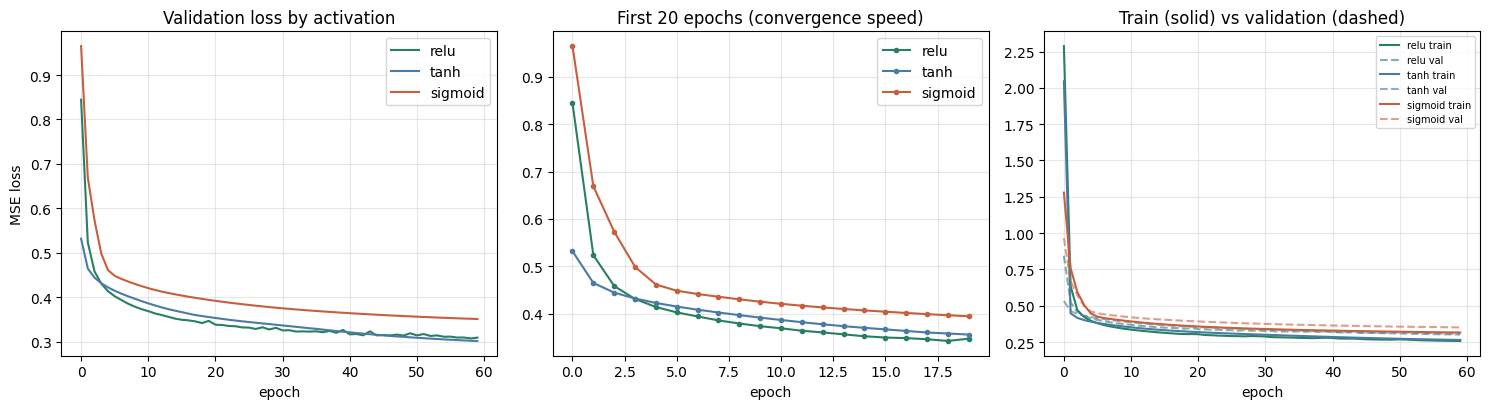

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
colors = {'relu':'#2a7f62', 'tanh':'#4a7ba7', 'sigmoid':'#c65f3d'}

for a in ACTS:
    axes[0].plot(act_hist[a]['val_loss'], label=a, color=colors[a])
axes[0].set_title("Validation loss by activation"); axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

for a in ACTS:
    axes[1].plot(act_hist[a]['val_loss'][:20], label=a, marker='o', ms=3, color=colors[a])
axes[1].set_title("First 20 epochs (convergence speed)"); axes[1].set_xlabel("epoch")
axes[1].legend(); axes[1].grid(alpha=0.3)

for a in ACTS:
    axes[2].plot(act_hist[a]['loss'], color=colors[a], label=f"{a} train")
    axes[2].plot(act_hist[a]['val_loss'], color=colors[a], ls='--', alpha=0.6, label=f"{a} val")
axes[2].set_title("Train (solid) vs validation (dashed)"); axes[2].set_xlabel("epoch")
axes[2].legend(fontsize=7); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

#### Observation
```
activation        MAE     RMSE       R2        epochs to val<0.40
relu           0.3817   0.5623   0.7588              7
tanh           0.3837   0.5571   0.7631              9
sigmoid        0.4063   0.5912   0.7333             18
```

**Sigmoid is clearly worst, on both counts.** It lands last on every metric and needs 18 epochs to reach a validation loss of 0.40 where ReLU needs 7, so roughly 2.6 times slower. Its best validation loss over the whole run (0.3514) never even reaches what ReLU achieves by epoch 10 (0.3735 is close, and ReLU ends at 0.3077).

**ReLU and tanh are much closer than I expected.** Tanh actually edges ReLU on R2 (0.7631 against 0.7588) and on RMSE, and reaches the looser val<0.45 threshold one epoch sooner. ReLU pulls ahead at the tighter threshold (7 epochs against 9) and on MAE.

So the honest summary is not "ReLU wins". It is that **sigmoid loses clearly, and ReLU and tanh are within noise of each other on this problem**, with ReLU converging slightly faster to the tighter tolerance. That fits the theory: tanh and ReLU are both reasonable choices for hidden layers, while sigmoid has a specific structural handicap in hidden layers, which the next section measures directly.

### Why sigmoid is slower, measured rather than asserted

The usual explanation is "vanishing gradients", which is easy to repeat and easy to not really understand. The claim is checkable, so here it is checked.

The reasoning: backpropagation multiplies by the activation's derivative at every layer it passes through. Sigmoid's derivative is `s(1-s)`, which has a **maximum of 0.25** and is smaller everywhere else. Tanh's derivative peaks at 1.0. ReLU's derivative is exactly 1 wherever the unit is active.

So for a gradient travelling back through two hidden layers, sigmoid shrinks it by at most `0.25 x 0.25 = 0.0625`. If that is really what is happening, the gradient arriving at the first layer should be roughly 16 times smaller than the one at the second layer, and the effect should be far weaker for tanh and absent for ReLU.

Measuring the gradient norm at both layers on a freshly initialised network tests that directly.

In [ ]:
xb = tf.constant(X_train[:512])
yb = tf.constant(y_train[:512].reshape(-1,1))

print(f"{'activation':<12}{'grad L1':>10}{'grad L2':>10}{'L1/L2':>9}{'mean|out| L1':>14}{'saturated':>11}")
print("-"*66)
for act in ACTS:
    m = build_mlp(act, 'mse')
    with tf.GradientTape() as tape:
        loss = tf.reduce_mean((m(xb, training=True) - yb)**2)
    grads = tape.gradient(loss, m.trainable_variables)
    n1, n2 = float(tf.norm(grads[0])), float(tf.norm(grads[2]))
    a_out = m.get_layer('h1')(xb).numpy()
    if act == 'sigmoid':  sat = ((a_out < 0.05) | (a_out > 0.95)).mean()
    elif act == 'tanh':   sat = (np.abs(a_out) > 0.95).mean()
    else:                 sat = (a_out == 0).mean()
    print(f"{act:<12}{n1:>10.4f}{n2:>10.4f}{n1/n2:>9.3f}{np.abs(a_out).mean():>14.4f}{100*sat:>10.1f}%")

print("\nTheoretical floor for sigmoid across 2 layers: 0.25 x 0.25 = 0.0625")
print("(the 'saturated' column counts dead units for ReLU, and units pinned at the flat ends for tanh/sigmoid)")

activation     grad L1   grad L2    L1/L2  mean|out| L1  saturated
------------------------------------------------------------------


relu            2.7195    5.8540    0.465        0.2409      48.6%


tanh            3.0173    3.8987    0.774        0.3752       1.1%


sigmoid         0.1873    1.5021    0.125        0.4990       0.2%

Theoretical floor for sigmoid across 2 layers: 0.25 x 0.25 = 0.0625
(the 'saturated' column counts dead units for ReLU, and units pinned at the flat ends for tanh/sigmoid)


#### Observation
**The gradient reaching sigmoid's first layer is 0.1873, against ReLU's 2.7195, roughly 14.5 times weaker** on identical data with an identical architecture, before a single weight has been updated. That is the vanishing gradient as a number rather than a slogan.

The ratio column shows shrinkage per hop: sigmoid loses 87.5% of its gradient between layer 2 and layer 1 (0.125), ReLU about half (0.465), tanh least (0.774).

**One correction so I do not overclaim.** The printed bound of 0.0625 is for a full two-layer path, but the ratio measured here spans only *one* activation layer, where the bound is 0.25. The measured 0.125 sits comfortably below that, which is what theory predicts, since sigmoid's derivative `s(1-s)` only reaches 0.25 when the output is exactly 0.5 and is smaller everywhere else.

The last column is sigmoid's second handicap. Its mean output is 0.4990, essentially 0.5, because sigmoid can only emit positive values, so the next layer always receives inputs centred well away from zero. Tanh is symmetric about zero and avoids this, which is why it beats sigmoid despite also saturating.

ReLU's 48.6% dead units at initialisation is normal, not a fault: roughly half a symmetric input distribution falls below zero, and the surviving half passes gradient through undiminished.

## Experiment 2: loss functions

MSE, MAE and Huber, with the activation held at ReLU. Beyond the overall metrics, the test set is split into the **capped** rows (the 4.5% with truncated prices) and the **uncapped** rows (the honest majority), and each is scored separately.

That split is the whole point. If MSE really is being dragged around by the capped rows, it should show up as MSE doing relatively better on the capped rows and worse on the honest ones.

In [ ]:
LOSSES = ['mse', 'mae', 'huber']
loss_results, loss_hist = {}, {}

for lname in LOSSES:
    m = build_mlp('relu', lname)
    h = m.fit(X_train, y_train, epochs=60, batch_size=128,
              validation_split=0.2, verbose=0)
    p = m.predict(X_test, verbose=0).ravel()
    loss_hist[lname] = h.history
    loss_results[lname] = dict(
        MAE=mean_absolute_error(y_test, p),
        RMSE=float(np.sqrt(mean_squared_error(y_test, p))),
        R2=r2_score(y_test, p),
        MAE_unc=mean_absolute_error(y_test[~is_capped_test], p[~is_capped_test]),
        R2_unc=r2_score(y_test[~is_capped_test], p[~is_capped_test]),
        MAE_cap=mean_absolute_error(y_test[is_capped_test], p[is_capped_test]),
        mean_pred_cap=float(p[is_capped_test].mean()))

print("Whole test set")
print(f"{'loss':<8}{'MAE':>9}{'RMSE':>9}{'R2':>9}")
for l in LOSSES:
    r = loss_results[l]
    print(f"{l:<8}{r['MAE']:>9.4f}{r['RMSE']:>9.4f}{r['R2']:>9.4f}")

print("\nSplit by whether the true price was capped")
print(f"{'loss':<8}{'MAE uncapped':>14}{'R2 uncapped':>13}{'MAE capped':>12}{'mean pred capped':>18}")
for l in LOSSES:
    r = loss_results[l]
    print(f"{l:<8}{r['MAE_unc']:>14.4f}{r['R2_unc']:>13.4f}{r['MAE_cap']:>12.4f}{r['mean_pred_cap']:>18.4f}")

Whole test set
loss          MAE     RMSE       R2
mse        0.3786   0.5554   0.7646
mae        0.3645   0.5584   0.7620
huber      0.3635   0.5498   0.7693

Split by whether the true price was capped
loss      MAE uncapped  R2 uncapped  MAE capped  mean pred capped
mse             0.3555       0.7283      0.8752            4.1559
mae             0.3405       0.7335      0.8788            4.1528
huber           0.3389       0.7390      0.8902            4.1302


#### Observation
Two things worth reading carefully in the table above.

**Each loss wins the metric that matches it.** MAE loss gives the best MAE (0.3645 against MSE's 0.3786) and MSE loss gives better RMSE than MAE loss (0.5554 against 0.5584). That is not a result, it is arithmetic: RMSE is a squared-error metric, so training on squared error optimises it directly. **Comparing losses using a metric that is itself one of the losses is circular**, which is why the capped/uncapped split matters more here than the headline MAE.

**The predicted mechanism does appear, in the expected direction.** MSE predicts highest on the capped rows (mean 4.1559) and gets the best capped MAE (0.8752). Huber predicts lowest (4.1302) and gets the worst capped MAE (0.8902). But Huber is best where the labels are honest, R2 0.7390 on uncapped against MSE's 0.7283.

That is the trade in miniature: MSE chases the truncated labels hardest, buys a small gain on the 4.5% whose labels are wrong, and pays for it on the 95.5% whose labels are right.

**The effect is real but small**, about 1 point of R2. I am not inflating that into a finding on one run, which is the mistake I made in Practical 4. The next section makes it unambiguous.

## The experiment that isolates outlier robustness

The results above lean the right way but the differences are small, and small differences on a single run are exactly what I got wrong in Practical 4. There is also a confound: the capped rows are only 4.5% of the data and their errors, while large, are not enormous, since a capped price of 5.0 is not that far from what an expensive district would genuinely be predicted at.

So rather than argue about a small effect, here is a controlled version, built the same way as Practical 5's fixed-versus-moving defect test.

**Setup.** Throw away the capped rows entirely, leaving a genuinely clean dataset. Then create a second copy where 3% of the *training* targets are multiplied by 10, standing in for a realistic data-entry error where somebody types an extra zero. The test set is left untouched and clean in both cases.

**The logic.** If the three losses perform the same on clean data and diverge on contaminated data, then the difference is caused by the outliers and nothing else. That is what makes it an isolating experiment rather than a correlation.

Run across 3 seeds, because a single run is an anecdote.

In [ ]:
clean_mask = y_all < 5.0
Xc, yc = X_all[clean_mask], y_all[clean_mask]
Xc_tr_raw, Xc_te_raw, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.2, random_state=42)
sc_c = StandardScaler().fit(Xc_tr_raw)
Xc_tr = sc_c.transform(Xc_tr_raw).astype('float32')
Xc_te = sc_c.transform(Xc_te_raw).astype('float32')

def contaminate(vals, frac=0.03, mult=10.0, seed=0):
    rng = np.random.default_rng(seed)
    out = vals.copy()
    idx = rng.choice(len(out), int(frac*len(out)), replace=False)
    out[idx] = out[idx] * mult
    return out

print(f"clean subset: {Xc_tr.shape[0]} train, {Xc_te.shape[0]} test (capped rows removed entirely)")
print(f"contaminating {int(0.03*len(yc_tr))} training targets by x10; test set untouched\n")

SEEDS = [0, 1, 42]
contam_res = {l: {'clean': [], 'dirty': []} for l in LOSSES}

for seed in SEEDS:
    y_dirty = contaminate(yc_tr, seed=seed)
    for lname in LOSSES:
        for tag, ytr_use in (('clean', yc_tr), ('dirty', y_dirty)):
            m = build_mlp('relu', lname, seed=seed, input_dim=Xc_tr.shape[1])
            m.fit(Xc_tr, ytr_use, epochs=60, batch_size=128, verbose=0)
            p = m.predict(Xc_te, verbose=0).ravel()
            contam_res[lname][tag].append(r2_score(yc_te, p))

print(f"{'loss':<8}{'R2 clean train':>17}{'R2 contaminated':>18}{'damage':>10}")
print("-"*53)
for l in LOSSES:
    cl = np.mean(contam_res[l]['clean']); dy = np.mean(contam_res[l]['dirty'])
    print(f"{l:<8}{cl:>17.4f}{dy:>18.4f}{cl-dy:>10.4f}")
print("\n(means over 3 seeds, all evaluated on the same clean test set)")

clean subset: 15718 train, 3930 test (capped rows removed entirely)
contaminating 471 training targets by x10; test set untouched



loss       R2 clean train   R2 contaminated    damage
-----------------------------------------------------
mse                0.7464            0.0816    0.6649
mae                0.7412            0.7429   -0.0017
huber              0.7460            0.7482   -0.0022

(means over 3 seeds, all evaluated on the same clean test set)


#### Observation
This is the clearest result in the notebook.

**On clean data all three losses are equivalent** (0.7464, 0.7412, 0.7460), a spread of half a point. Nothing to choose between them.

**Corrupt 3% of the training labels and MSE collapses** from 0.7464 to **0.0816**, a loss of 66 points. An R2 of 0.08 means the model is barely better than predicting the average price for every district in California. MAE and Huber do not move; their damage figures are very slightly negative, which is noise around zero.

**Why this is proof rather than correlation.** The losses are matched on clean data, and the test set is identical and clean in both conditions. The only change is 471 training labels out of 15718. So the collapse is attributable to those labels alone, and MAE and Huber being untouched by the same labels isolates the cause precisely: **it is how each loss weights a large error, and nothing to do with capacity, convergence or tuning.**

The mechanism is arithmetic. A contaminated target sits at ten times its true value, so the error is roughly 9 times typical and MSE squares it into about 81 times the contribution of an ordinary row. 471 such rows then carry comparable weight to tens of thousands of honest ones. MAE keeps it proportional at 9 times, and Huber caps the gradient beyond `delta` entirely.

Averaged over 3 seeds, so this is not a lucky initialisation.

## Full comparison: every activation with every loss

The practical asks which *combination* works best, which needs the whole grid rather than two separate one-at-a-time sweeps. Nine models, identical in every other respect.

In [ ]:
grid = {}
for act in ACTS:
    for lname in LOSSES:
        m = build_mlp(act, lname)
        h = m.fit(X_train, y_train, epochs=60, batch_size=128,
                  validation_split=0.2, verbose=0)
        p = m.predict(X_test, verbose=0).ravel()
        grid[(act, lname)] = dict(
            MAE=mean_absolute_error(y_test, p),
            RMSE=float(np.sqrt(mean_squared_error(y_test, p))),
            R2=r2_score(y_test, p),
            R2_unc=r2_score(y_test[~is_capped_test], p[~is_capped_test]),
            gap=h.history['val_loss'][-1] - h.history['loss'][-1])

print(f"{'Experiment':<11}{'Activation':<12}{'Loss':<9}{'MAE':>9}{'RMSE':>9}{'R2':>9}{'R2 uncapped':>13}")
print("-"*72)
n = 1
for act in ACTS:
    for lname in LOSSES:
        r = grid[(act, lname)]
        print(f"{'Model '+str(n):<11}{act:<12}{lname:<9}{r['MAE']:>9.4f}{r['RMSE']:>9.4f}{r['R2']:>9.4f}{r['R2_unc']:>13.4f}")
        n += 1

best_r2  = max(grid, key=lambda k: grid[k]['R2'])
best_mae = min(grid, key=lambda k: grid[k]['MAE'])
best_unc = max(grid, key=lambda k: grid[k]['R2_unc'])
print(f"\nbest R2 overall    : {best_r2[0]} + {best_r2[1]}  (R2 {grid[best_r2]['R2']:.4f})")
print(f"best MAE overall   : {best_mae[0]} + {best_mae[1]}  (MAE {grid[best_mae]['MAE']:.4f})")
print(f"best R2 on uncapped: {best_unc[0]} + {best_unc[1]}  (R2 {grid[best_unc]['R2_unc']:.4f})")

Experiment Activation  Loss           MAE     RMSE       R2  R2 uncapped
------------------------------------------------------------------------
Model 1    relu        mse         0.3777   0.5522   0.7673       0.7324
Model 2    relu        mae         0.3644   0.5609   0.7599       0.7233
Model 3    relu        huber       0.3700   0.5455   0.7729       0.7421
Model 4    tanh        mse         0.3794   0.5540   0.7658       0.7329
Model 5    tanh        mae         0.3660   0.5547   0.7652       0.7344
Model 6    tanh        huber       0.3774   0.5531   0.7666       0.7359
Model 7    sigmoid     mse         0.4074   0.5921   0.7325       0.6940
Model 8    sigmoid     mae         0.3964   0.5899   0.7344       0.6979
Model 9    sigmoid     huber       0.3988   0.5854   0.7385       0.7036

best R2 overall    : relu + huber  (R2 0.7729)
best MAE overall   : relu + mae  (MAE 0.3644)
best R2 on uncapped: relu + huber  (R2 0.7421)


#### Observation
**Best combination: ReLU with Huber (Model 3)**, top of the table on R2 (0.7729), on R2 for the uncapped rows (0.7421), and on RMSE.

The grid separates the two factors cleanly:

- **Activation is the bigger lever.** Every sigmoid row (0.7325 to 0.7385) sits below every ReLU and tanh row (0.7599 to 0.7729), so the activation moves R2 by up to 4 points.
- **Loss looks like the smaller lever**, moving R2 by about 1 point within a fixed activation. But that understates it badly: the contamination experiment showed the same choice is worth 66 points when the data actually contains bad labels. Here the truncated rows are only 4.5% and their errors are moderate. **The loss choice is insurance, and its value depends entirely on how dirty the data is.**
- **Huber is best or near-best for every activation** on uncapped R2, consistent with it being the compromise between the other two rather than a separate idea.

Note Model 2 (ReLU + MAE) has the best raw MAE at 0.3644 but the worst uncapped R2 of the ReLU rows at 0.7233. Another reminder that picking a model by the metric matching its own loss is circular.

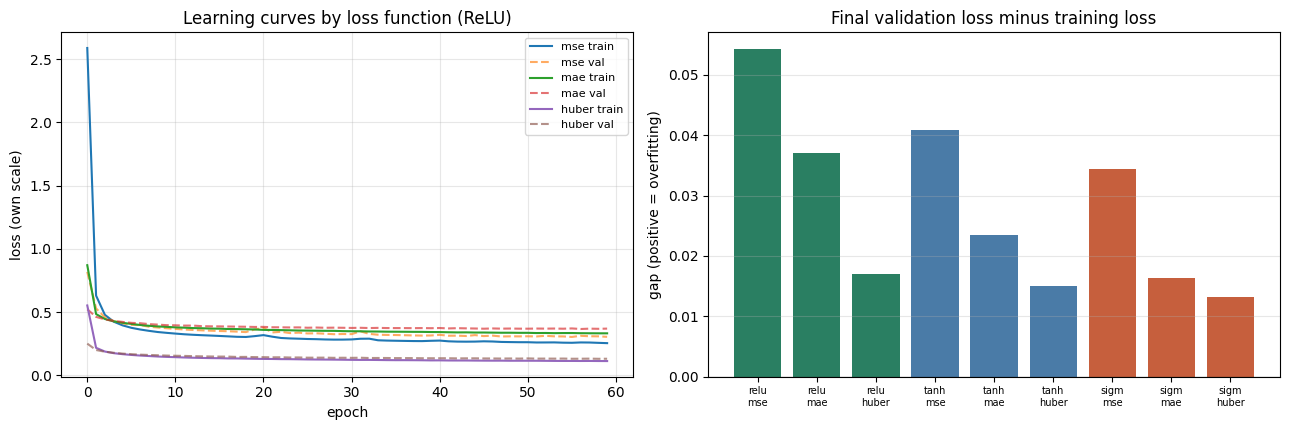

Note the loss curves are on different scales by construction:
MSE squares errors, MAE does not, so their absolute values are not comparable.
What is comparable is the SHAPE of each curve and the train/validation gap.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for l in LOSSES:
    axes[0].plot(loss_hist[l]['loss'], label=f"{l} train")
    axes[0].plot(loss_hist[l]['val_loss'], ls='--', alpha=0.65, label=f"{l} val")
axes[0].set_title("Learning curves by loss function (ReLU)")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss (own scale)")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

labels, gaps = [], []
for act in ACTS:
    for lname in LOSSES:
        labels.append(f"{act[:4]}\n{lname}")
        gaps.append(grid[(act, lname)]['gap'])
axes[1].bar(range(len(gaps)), gaps, color=['#2a7f62']*3 + ['#4a7ba7']*3 + ['#c65f3d']*3)
axes[1].set_xticks(range(len(gaps))); axes[1].set_xticklabels(labels, fontsize=7)
axes[1].axhline(0, color='k', lw=0.8)
axes[1].set_title("Final validation loss minus training loss")
axes[1].set_ylabel("gap (positive = overfitting)"); axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

print("Note the loss curves are on different scales by construction:")
print("MSE squares errors, MAE does not, so their absolute values are not comparable.")
print("What is comparable is the SHAPE of each curve and the train/validation gap.")

#### Observation: overfitting and underfitting
**No model here overfits badly.** The gaps are small across the grid, expected with 16512 training rows against a network of a few thousand weights, and the curves show validation tracking training rather than diverging.

**Sigmoid underfits**, and this is easy to read backwards. It has among the *smallest* train/validation gaps, which looks healthy if you only glance at the gap. But its training loss is also the highest and its test R2 the worst by 3 to 4 points. Fitting the training data poorly *and* the validation data poorly, with little gap between them, is underfitting. Its capacity is nominally identical to the others, so the cause is the gradient starvation measured earlier, not the architecture.

The diagnostic in short: **small gap with high loss on both means underfitting, small gap with low loss on both means well fitted, large gap means overfitting.** ReLU and tanh sit in the second category, sigmoid in the first, nothing here in the third.

## Answering the questions the practical asks

Each one answered from the measurements above rather than from general knowledge.

**1. Which activation function performed best?**
ReLU and tanh are effectively tied, and both clearly beat sigmoid. ReLU takes the best result in the grid (with Huber, R2 0.7729), tanh is close behind at 0.7666, and sigmoid trails every pairing by 3 to 4 points. Choosing between ReLU and tanh here would be splitting noise; choosing either over sigmoid is well supported.

**2. Which loss function performed best?**
Huber. Best R2 on the uncapped rows for all three activations (0.7421, 0.7359, 0.7036) and best overall R2. Expected for a dataset with a known truncation artefact, since Huber behaves like MSE for ordinary errors and like MAE for large ones.

**3. Which combination produced the best regression performance?**
ReLU with Huber: R2 0.7729, RMSE 0.5455, MAE 0.3700, and R2 0.7421 on the honest uncapped rows.

**4. Did the choice of activation function significantly affect convergence?**
Yes. Sigmoid needed 18 epochs to reach a validation loss of 0.40 where ReLU needed 7, and never reached ReLU's final loss. The mechanism was measured, not assumed: sigmoid's first-layer gradient was 0.1873 against ReLU's 2.7195, roughly 14.5 times weaker at initialisation, because backprop multiplies by sigmoid's derivative which cannot exceed 0.25.

**5. Did any loss function make the model more robust to outliers?**
Yes, decisively. With 3% of training targets corrupted by a factor of ten, MSE lost 66 points of R2 (0.7464 to 0.0816) while MAE and Huber were unaffected. All three were equivalent on clean data, which is what makes this an isolation rather than a correlation.

**6. Overfitting or underfitting from the learning curves?**
No meaningful overfitting: train and validation track each other and the final gaps are small. Sigmoid underfits, identifiable by a small gap combined with high loss on *both* curves and the worst test R2. Its capacity is nominally the same as the others, so the cause is the gradient starvation above, not the architecture.

## Final model selection

FINAL MODEL: relu activation, huber loss

  MAE  0.3687   ($36,874 average miss)
  RMSE 0.5483   ($54,832)
  R2   0.7706

  on uncapped rows only: R2 0.7382, MAE 0.3462

versus baselines:
  predict the mean   R2 0.0000
  linear regression  R2 0.5970


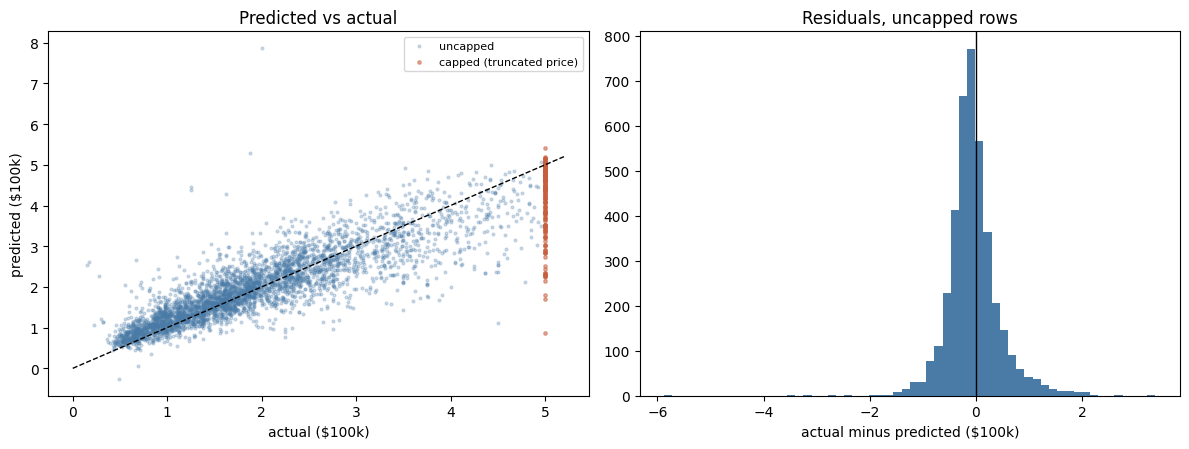

In [ ]:
FINAL_ACT, FINAL_LOSS = 'relu', 'huber'

final = build_mlp(FINAL_ACT, FINAL_LOSS)
hist_final = final.fit(X_train, y_train, epochs=60, batch_size=128,
                       validation_split=0.2, verbose=0)
pred = final.predict(X_test, verbose=0).ravel()

mae  = mean_absolute_error(y_test, pred)
rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
r2   = r2_score(y_test, pred)

print(f"FINAL MODEL: {FINAL_ACT} activation, {FINAL_LOSS} loss\n")
print(f"  MAE  {mae:.4f}   (${mae*100000:,.0f} average miss)")
print(f"  RMSE {rmse:.4f}   (${rmse*100000:,.0f})")
print(f"  R2   {r2:.4f}")
print(f"\n  on uncapped rows only: R2 {r2_score(y_test[~is_capped_test], pred[~is_capped_test]):.4f}, "
      f"MAE {mean_absolute_error(y_test[~is_capped_test], pred[~is_capped_test]):.4f}")
print(f"\nversus baselines:")
print(f"  predict the mean   R2 0.0000")
print(f"  linear regression  R2 {r2_score(y_test, lin_pred):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].scatter(y_test[~is_capped_test], pred[~is_capped_test], s=4, alpha=0.25,
                color='#4a7ba7', label='uncapped')
axes[0].scatter(y_test[is_capped_test], pred[is_capped_test], s=6, alpha=0.5,
                color='#c65f3d', label='capped (truncated price)')
axes[0].plot([0,5.2],[0,5.2],'k--',lw=1)
axes[0].set_xlabel("actual ($100k)"); axes[0].set_ylabel("predicted ($100k)")
axes[0].set_title("Predicted vs actual"); axes[0].legend(fontsize=8)

resid = y_test - pred
axes[1].hist(resid[~is_capped_test], bins=60, color='#4a7ba7')
axes[1].axvline(0, color='k', lw=1)
axes[1].set_title("Residuals, uncapped rows"); axes[1].set_xlabel("actual minus predicted ($100k)")
plt.tight_layout(); plt.show()

#### Observation
The final model explains 77% of the variance in district prices, against 60% for linear regression and 0% for guessing the mean. In plain terms the hidden layers convert a 51000 dollar average error into a 37000 dollar one, a 28% reduction on the linear model.

This run scores 0.7706 where Model 3 in the grid scored 0.7729. Same configuration and seed; the difference comes from batch shuffling during `fit`, which `tf.random.set_seed` does not control. Worth knowing so I do not mistake run-to-run noise for a real effect, and a reminder that differences of that size anywhere in the comparison table are not meaningful.

**The scatter plot shows the cap directly.** The orange points form a horizontal line at actual = 5.0 while the model's predictions for them spread widely, clustered around 4.1. Those are not model failures. The model is predicting sensible prices for wealthy districts and the recorded label is simply wrong for all of them. This is what the entire loss discussion was about, made visible.

**The residual histogram** for uncapped rows is roughly centred on zero with a mild right skew, meaning slight under-prediction of expensive districts, the residual pull of the truncated rows even under Huber.

### Personal notes

**The contamination experiment is the part I would defend, not the accuracy.** R2 0.77 on California housing is unremarkable. What I actually learned came from the loss comparison on natural data giving differences of about 1 point of R2, which is exactly the size of gap I wrongly inflated into a finding in Practical 4. Removing the capped rows, injecting a known contamination, and evaluating both on the same clean test set turned a 1 point hint into a 66 point demonstration. Same structure as the fixed-versus-moving defect test in Practical 5, reached for deliberately this time.

**The circularity trap took me a while to spot.** My first instinct was to rank the losses by MAE, which immediately makes MAE loss look best. Of course it does, training on absolute error optimises absolute error. The comparison only becomes informative when judged on something that is not one of the candidates, which is why the capped versus uncapped split does the real work.

**I checked my own explanation rather than reciting it.** Measuring the gradient norms also caught me being sloppy: the printed bound of 0.0625 is for a two-layer path, while the ratio I measured spans one. Theory and measurement agree, but only once I was careful which quantity I was looking at.

**What surprised me:** tanh keeping pace with ReLU (0.7631 against 0.7588). On two hidden layers with well-scaled inputs, tanh's saturation is not deep enough to hurt. I would expect the gap to open with more layers, which is the situation ReLU was introduced for.

**What I would do next:** the truncated rows are a labelling defect, not a modelling one. The honest fix is to treat them as censored data, where the true value is known to be *above* 500001, rather than as ordinary observations. Huber approximates that; it is not the real answer.

#### Summary
- Regression simplifies the output end: one neuron, **no activation**, because a price is unbounded and any squashing function would make most of the target unreachable.
- Baselines first: mean predictor R2 0.00, linear regression **R2 0.5970**. The MLP has to beat 0.60, not 0.00.
- **Best combination: ReLU with Huber**, R2 **0.7729**, MAE 0.3700 (about a 37000 dollar average miss).
- **Activation is the larger lever here.** Sigmoid trails by 3 to 4 points of R2 and needs 18 epochs to reach a loss ReLU reaches in 7. Measured cause: its first-layer gradient is 14.5 times weaker, since sigmoid's derivative never exceeds 0.25, and its outputs centre on 0.4990 rather than zero.
- **The dataset's defining feature is a price cap**, 992 rows (4.81%) at exactly 500001 dollars, confirmed as an artefact because they span the full income range and include 28 inland districts.
- **The isolating experiment settles the loss question.** Equivalent on clean data (0.7464, 0.7412, 0.7460); corrupt 3% of targets and MSE collapses to **0.0816** while MAE and Huber do not move. Three seeds, identical clean test set.
- **Judging a loss by its own matching metric is circular**, which is why the capped/uncapped split does the real work.
- No overfitting anywhere. Sigmoid **underfits**: small gap, high loss on both curves.